In [1]:
#Importing Dependencies
import cellrank as cr
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import palantir
from cellrank.kernels import PseudotimeKernel
from cellrank.kernels import CytoTRACEKernel
import scipy.stats as st

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.simplefilter("ignore", category=UserWarning)
warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)


In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor = 'white')

scanpy==1.10.1 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.1.4 scikit-learn==1.2.2 statsmodels==0.14.0 igraph==0.11.5 pynndescent==0.5.13


In [3]:
# Loading Seurat converted file
seurat = sc.read_h5ad('Seurat_Full.h5ad') 

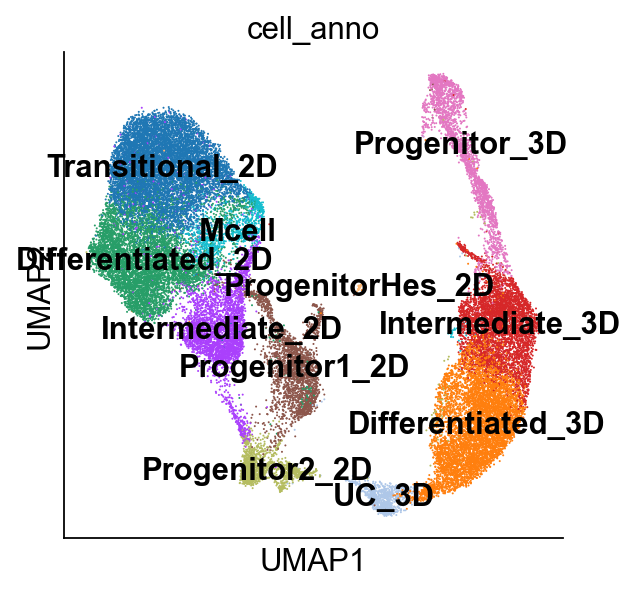

In [4]:
# Plotting UMAP
sc.pl.umap(seurat, color = "cell_anno", legend_loc = 'on data')

In [5]:
# Making AnnData with Seurat Information and keeping PCA and UMAP information
matrix = seurat.X # Extracting counts
var = sc.get.var_df(seurat) # Extracting Features
obs = sc.get.obs_df(seurat) # Extracting Barcodes

# Making New AnnData
adata = sc.AnnData(matrix,
                  obs,
                  var)

# Including Reduction Information
adata.obs = seurat.obs
adata.obsm = seurat.obsm
adata

AnnData object with n_obs × n_vars = 36777 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'nucleosome_signal', 'nucleosome_percentile', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'integrated_snn_res.0.8', 'integrated_snn_res.1.2', 'integrated_snn_res.0.35', 'res_35', 'cell_anno'
    obsm: 'X_pca', 'X_umap'

In [6]:
#Doing variance clean up for scanpy
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 36777 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'nucleosome_signal', 'nucleosome_percentile', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'integrated_snn_res.0.8', 'integrated_snn_res.1.2', 'integrated_snn_res.0.35', 'res_35', 'cell_anno'
    obsm: 'X_pca', 'X_umap'

In [7]:
# Normalizing and Transforming Counts
sc.pp.normalize_per_cell(adata)
palantir.preprocess.log_transform(adata)
sc.pp.highly_variable_genes(adata,
                            n_top_genes= 3000)
adata

normalizing by total count per cell
    finished (0:00:02): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


AnnData object with n_obs × n_vars = 36777 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'nucleosome_signal', 'nucleosome_percentile', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'integrated_snn_res.0.8', 'integrated_snn_res.1.2', 'integrated_snn_res.0.35', 'res_35', 'cell_anno', 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'X_pca', 'X_umap'

In [8]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(adata)
sc.pp.neighbors(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:22)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


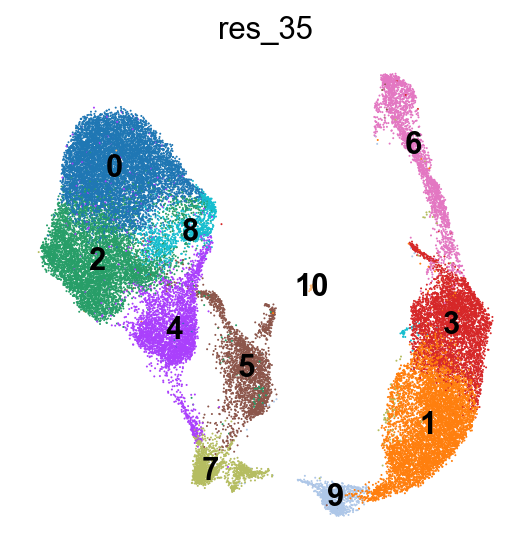

In [9]:
# Use scanpy functions to visualize umap
sc.pl.embedding(
    adata,
    basis="umap",
    color = "res_35",
    frameon=False,
    legend_loc = "on data"
)

In [10]:
#Doing Magic
imputed_X = palantir.utils.run_magic_imputation(adata)

#adata.write_h5ad('Full_Seurat_Magic.h5ad')